In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

In [3]:
# 1. LES DATA
# --------------------------------------------------
print("Leser data ...")
train = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/bysykkel_train.csv", parse_dates=["ds"])
test = pd.read_csv("https://raw.githubusercontent.com/jensmorten/sykkelprofet/refs/heads/main/konkurranse/test_compete.csv", parse_dates=["ds"])
test_truth=pd.read_csv("test_target_secret.csv", parse_dates=["ds"])
train = train.sort_values("ds")
test = test.sort_values("ds")
test_truth=test_truth.sort_values("ds")
print("done!")

Leser data ...
done!


In [4]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [5]:
def create_multistep_sequences(data, window, horizon):
    X, y = [], []
    
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window:i+window+horizon])
        
    return np.array(X), np.array(y)

In [6]:
horizon = 8
window = 8

In [7]:
print(len(test))

1067


In [8]:
# ---- 1. Skalering ----
#scaler = MinMaxScaler()
scaler=StandardScaler()
scaled_train = scaler.fit_transform(train[["y"]])

X_all, y_all = create_sequences(scaled_train, window)

# reshape for LSTM
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

# ---- 3. Kronologisk split ----
split_index = int(len(X_all) * 0.90)

X_tr = X_all[:split_index]
y_tr = y_all[:split_index]

X_val = X_all[split_index:]
y_val = y_all[split_index:]

print("Train shape:", X_tr.shape)
print("Val shape:", X_val.shape)

Train shape: (11146, 8, 1)
Val shape: (1239, 8, 1)


In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    min_delta=0.0001,
    verbose=1
)

model_lstm = Sequential([
    Input(shape=(window, 1)),
    LSTM(128, activation='tanh', return_sequences=True),
    #LSTM(256, activation='tanh', return_sequences=True),
    #LSTM(512, activation='tanh', return_sequences=True),
    #LSTM(1024, activation='tanh', return_sequences=True),
    #LSTM(512, activation='tanh', return_sequences=True),
    #LSTM(256, activation='tanh', return_sequences=True),
    #LSTM(128, activation='tanh', return_sequences=True),
    LSTM(64, activation='tanh'),
    Dense(horizon)   # ← viktig!
])

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

history = model_lstm.fit(
    X_tr,
    y_tr,
    epochs=100,
    batch_size=8,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.3957 - val_loss: 0.1953
Epoch 2/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.3082 - val_loss: 0.1581
Epoch 3/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2270 - val_loss: 0.1164
Epoch 4/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1846 - val_loss: 0.1092
Epoch 5/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1651 - val_loss: 0.1045
Epoch 6/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1495 - val_loss: 0.1002
Epoch 7/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1311 - val_loss: 0.0971
Epoch 8/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1201 - val_loss: 0.1020
Epoch 9/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1138 - val_loss: 0.1031
Epoch 10/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.1091 - val_loss: 0.1015
Epoch 11/100
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1057 - val_loss: 0.0991
Epoch 12

In [10]:
#model_lstm = Sequential([
    #LSTM(100, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(75, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(50, activation='tanh',return_sequences=True, input_shape=(window, 1)),
#    LSTM(10, activation='tanh'), 
#    Dense(1)
#])

#model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss='mse')

#model_lstm.fit(X_train, y_train, epochs=50, batch_size=112, verbose=1)

In [11]:
#last_window = scaled_train[-window:]
#last_window = last_window.reshape((1, window, 1))

#multi_pred_scaled = model_lstm.predict(last_window)

#multi_pred = scaler.inverse_transform(
#    multi_pred_scaled.reshape(-1,1)
#).flatten()

In [12]:
history = scaled_train[-window:].flatten().tolist()
predictions = []

steps_remaining = len(test)

while steps_remaining > 0:
    
    x_input = np.array(history[-window:]).reshape((1, window, 1))
    
    block_pred = model_lstm.predict(x_input, verbose=0).flatten()
    
    # berre ta det vi faktisk treng
    block_pred = block_pred[:steps_remaining]
    
    predictions.extend(block_pred)
    history.extend(block_pred)
    
    steps_remaining -= len(block_pred)

In [13]:
lstm_pred = scaler.inverse_transform(
    np.array(predictions).reshape(-1,1)
).flatten()

In [14]:
from sklearn.metrics import mean_squared_error

rmse_lstm = mean_squared_error(
    test_truth["y"].values,
    lstm_pred,
    squared=False
)

print("Direct multi-step LSTM RMSE:", rmse_lstm)

Direct multi-step LSTM RMSE: 152.1597555182433


C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


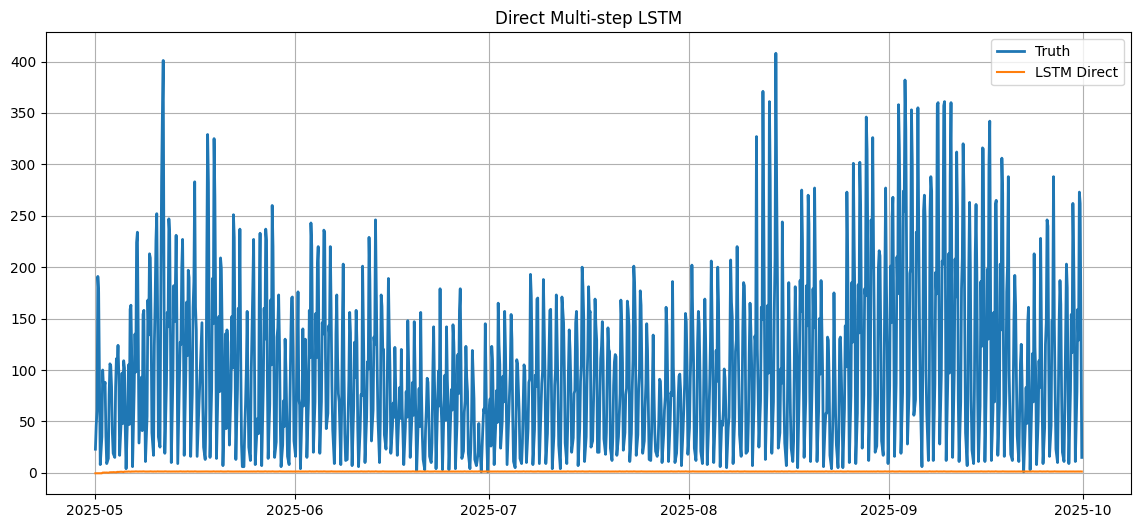

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test_truth["ds"], test_truth["y"], label="Truth", linewidth=2)
plt.plot(test_truth["ds"], predictions, label="LSTM Direct")

plt.legend()
plt.grid(True)
plt.title("Direct Multi-step LSTM")
plt.show()